# Proof of Concept with OpenCV 01

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

In [2]:
def show_image(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

## Load Image

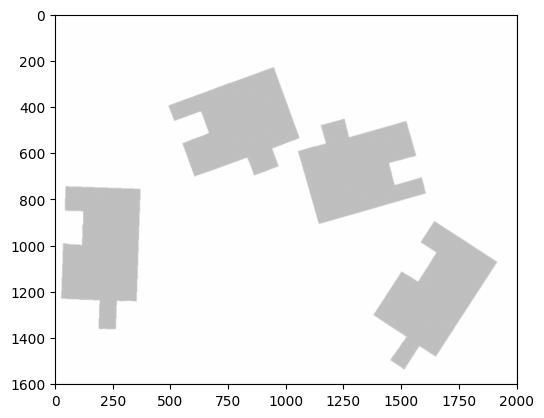

In [3]:
image = cv2.imread("../assets/puzzle_images/simulator_01.png")
show_image(image)

## Object Detection

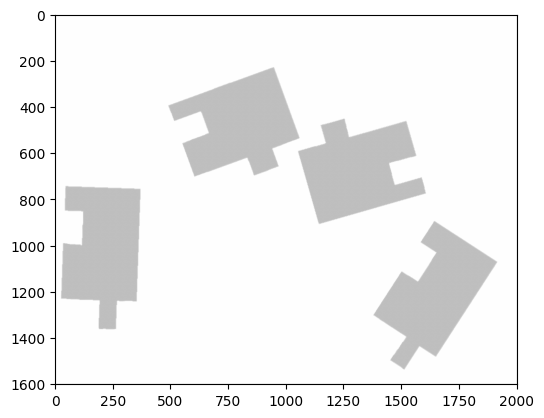

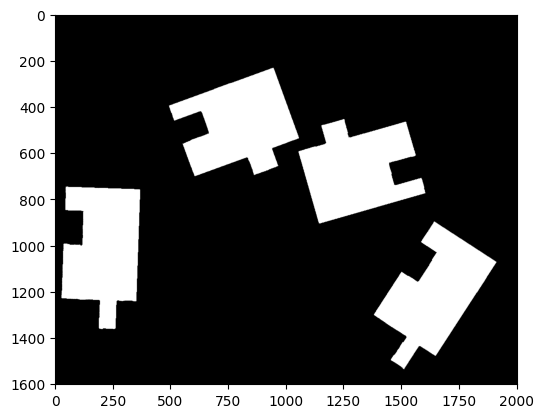

In [4]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
show_image(gray_image)

_, thresh = cv2.threshold(gray_image, 200, 255, cv2.THRESH_BINARY_INV)
show_image(thresh)

In [5]:
def draw_bounding_boxes(image, boxes):
    image = np.copy(image)

    for box in boxes:
        x1, y1, x2, y2 = [int(coord) for coord in box]
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 10)

    return image

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

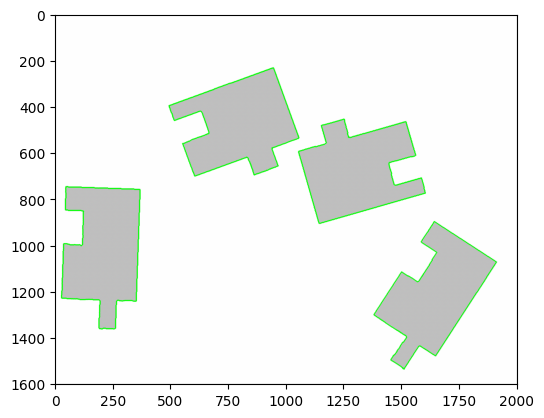

In [6]:
pieces_image = image.copy()
pieces_image = cv2.drawContours(pieces_image, contours, -1, (0, 255, 0), 3)

show_image(pieces_image)

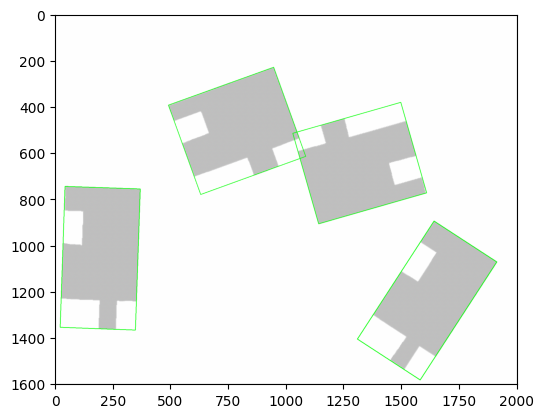

In [7]:
pieces_image = image.copy()
pieces = []

for i, c in enumerate(contours):
    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect).astype(np.float32)

    # Compute width and height from the box
    w = int(np.linalg.norm(box[1] - box[0]))
    h = int(np.linalg.norm(box[2] - box[1]))

    # Define the destination points for a straight rectangle
    dst_pts = np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ], dtype=np.float32)

    # Perspective transform matrix
    M = cv2.getPerspectiveTransform(box, dst_pts)

    # Warp (crop) the rotated piece
    cropped = cv2.warpPerspective(thresh, M, (w, h))
    pieces.append(cropped)

    # Draw contour box on visualization image
    cv2.drawContours(pieces_image, [box.astype(int)], 0, (0, 255, 0), 2)

show_image(pieces_image)

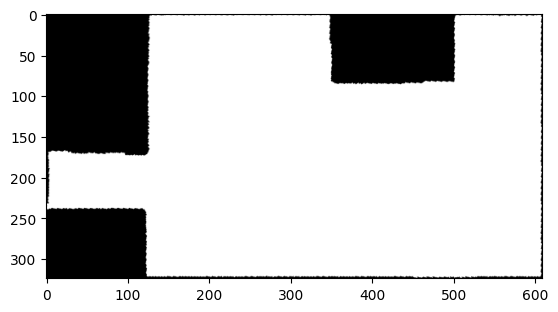

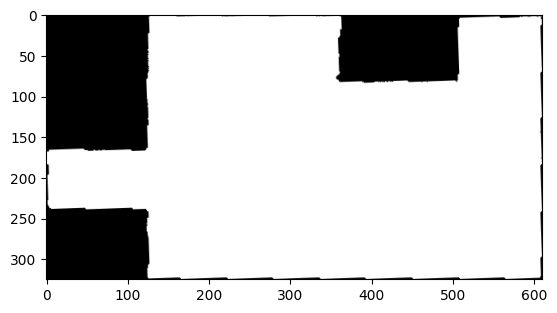

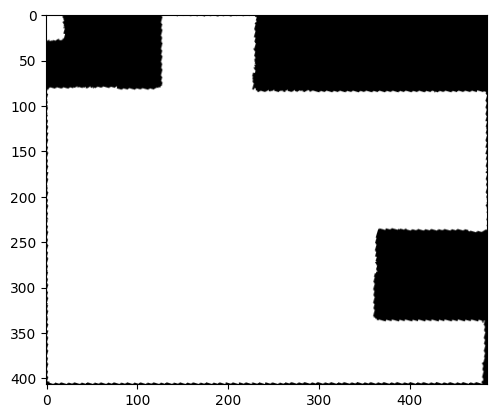

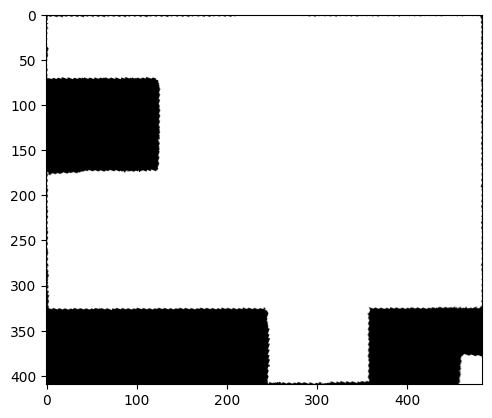

In [12]:
for p in pieces:
    show_image(p)

## Remove overlaps

Mask out the piece by largest white area. The small overlaps in the edges need to go.

In [ ]:
masked_pieces = []

for p in pieces:
    contours, _ = cv2.findContours(p, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        masked_pieces.append(p)
        continue

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(p)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    result = cv2.bitwise_and(p, p, mask=mask)
    masked_pieces.append(result)

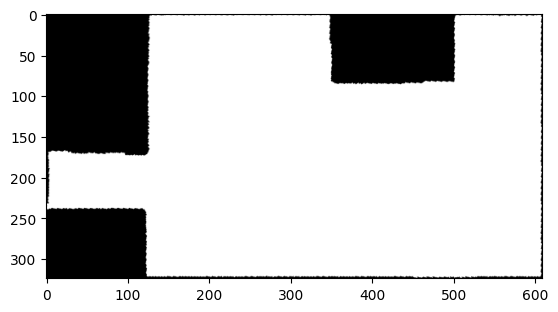

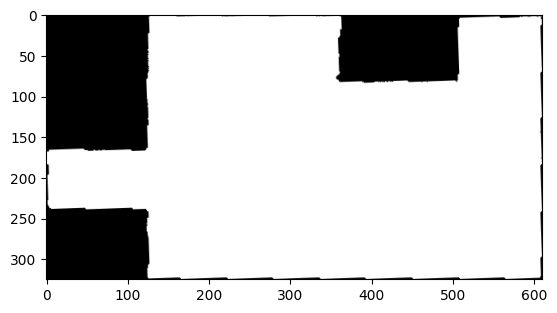

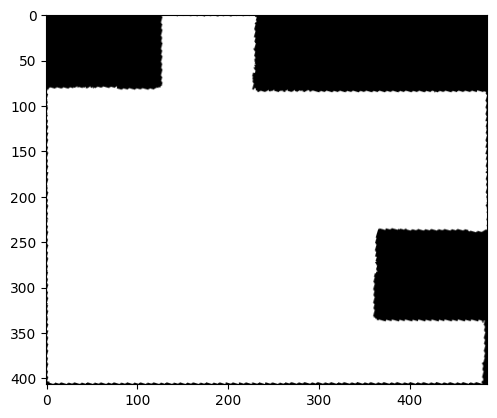

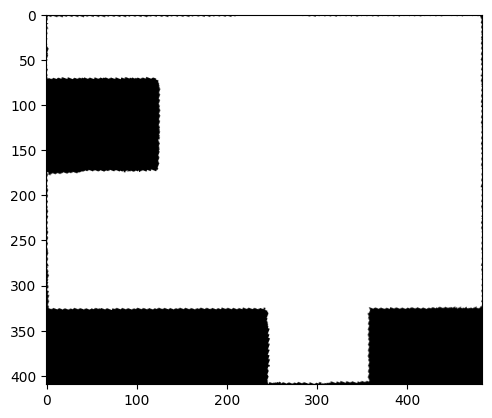

In [ ]:
for p in masked_pieces:
    show_image(p)

## Smooth contours

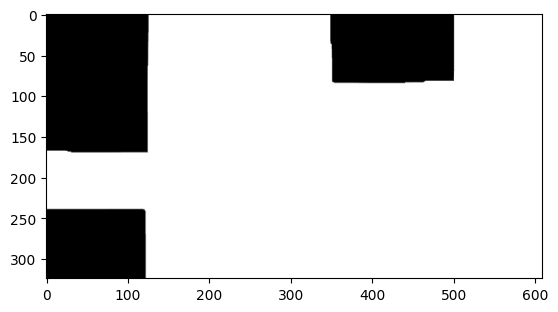

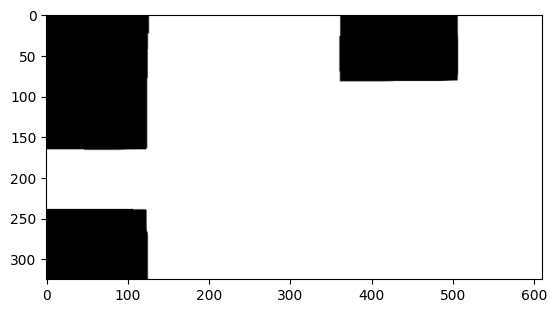

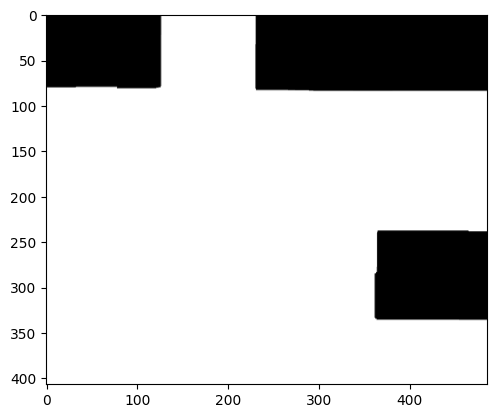

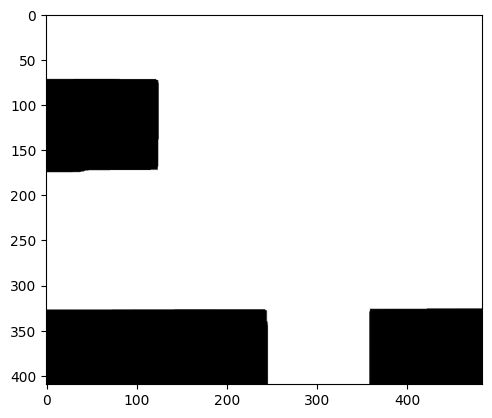

In [37]:
def smooth_mask(thresh, kernel_size=5, iterations=10):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    # Close small gaps, then open small noise
    smooth = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    smooth = cv2.morphologyEx(smooth, cv2.MORPH_OPEN, kernel, iterations=iterations)
    return smooth

smoothed_pieces = []

for p in masked_pieces:
    sp = smooth_mask(p)
    smoothed_pieces.append(sp)
    show_image(sp)

## Vectorize edges

Piece #0


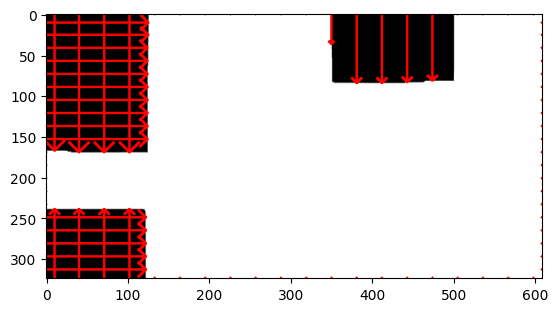

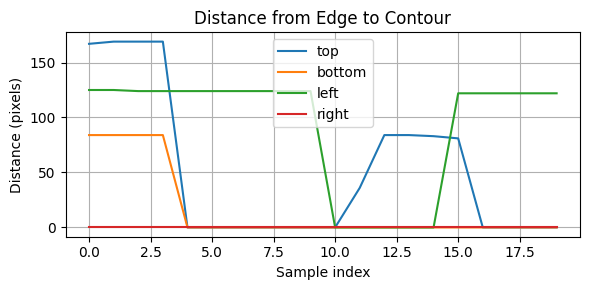

Piece #1


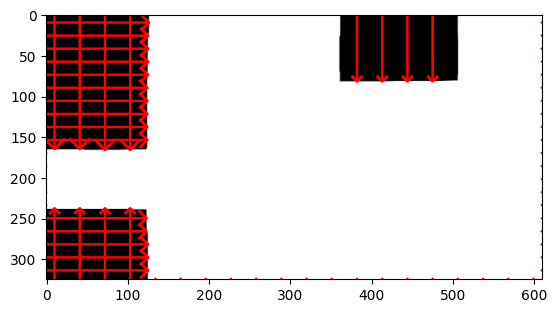

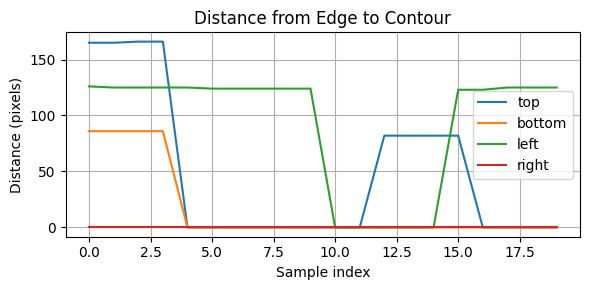

Piece #2


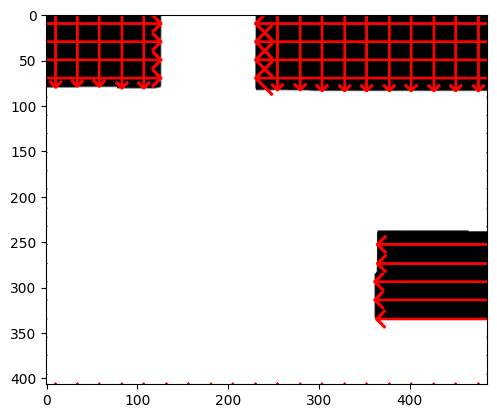

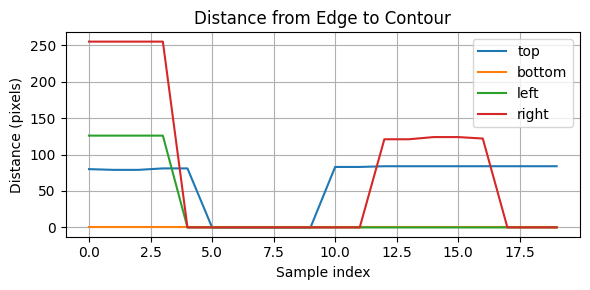

Piece #3


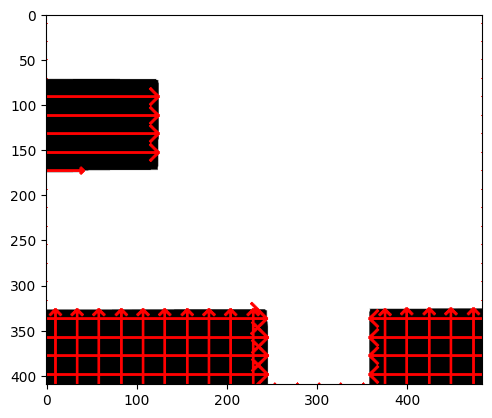

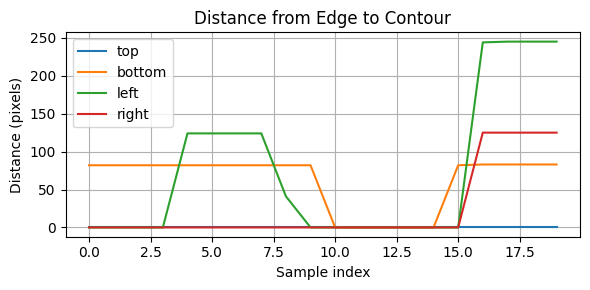

In [43]:
def measure_edge_distances(thresh, n_vectors=10, margin=10):
    """Measure perpendicular distances from each image edge to the first contour pixel."""
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    h, w = thresh.shape
    x_samples = np.linspace(margin, w - 1 - margin, n_vectors, dtype=np.int32)
    y_samples = np.linspace(margin, h - 1 - margin, n_vectors, dtype=np.int32)

    distances = {
        "top": [],
        "bottom": [],
        "left": [],
        "right": []
    }

    # Measure top and bottom
    for x in x_samples:
        # Top
        for y in range(h):
            if mask[y, x] > 0:
                distances["top"].append(((x, 0), (x, y)))
                break

        # Bottom
        for y in range(h - 1, -1, -1):
            if mask[y, x] > 0:
                distances["bottom"].append(((x, h - 1), (x, y)))
                break

    # Measure left and right
    for y in y_samples:
        # Left
        for x in range(w):
            if mask[y, x] > 0:
                distances["left"].append(((0, y), (x, y)))
                break

        # Right
        for x in range(w - 1, -1, -1):
            if mask[y, x] > 0:
                distances["right"].append(((w - 1, y), (x, y)))
                break

    return distances


def draw_edge_vectors(thresh, distances, color=(0, 0, 255), thickness=2):
    """Draws precomputed edge vectors onto the thresholded image."""
    img_out = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

    for edge_points in distances.values():
        for start, end in edge_points:
            cv2.arrowedLine(img_out, start, end, color, thickness, tipLength=0.1)

    return img_out

def plot_edge_distances(distances):
    """Plot distance (in pixels) from each edge to contour."""
    edge_names = ["top", "bottom", "left", "right"]

    plt.figure(figsize=(6, 3))
    for edge in edge_names:
        edge_points = distances.get(edge, [])
        if not edge_points:
            continue

        # Compute Euclidean distances
        dist_vals = [np.hypot(e[1][0] - e[0][0], e[1][1] - e[0][1]) for e in edge_points]
        plt.plot(dist_vals, label=edge)

    plt.title("Distance from Edge to Contour")
    plt.xlabel("Sample index")
    plt.ylabel("Distance (pixels)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for i, p in enumerate(smoothed_pieces):
    print(f"Piece #{i}")
    dist_info = measure_edge_distances(p, n_vectors=20, margin=10)
    vis = draw_edge_vectors(p, dist_info)
    show_image(vis)
    plot_edge_distances(dist_info)

Piece #0
{'top': [((np.int32(10), 0), (np.int32(10), 167)), ((np.int32(15), 0), (np.int32(15), 167)), ((np.int32(21), 0), (np.int32(21), 167)), ((np.int32(27), 0), (np.int32(27), 168)), ((np.int32(33), 0), (np.int32(33), 169)), ((np.int32(39), 0), (np.int32(39), 169)), ((np.int32(45), 0), (np.int32(45), 169)), ((np.int32(51), 0), (np.int32(51), 169)), ((np.int32(57), 0), (np.int32(57), 169)), ((np.int32(63), 0), (np.int32(63), 169)), ((np.int32(69), 0), (np.int32(69), 169)), ((np.int32(75), 0), (np.int32(75), 169)), ((np.int32(81), 0), (np.int32(81), 169)), ((np.int32(87), 0), (np.int32(87), 169)), ((np.int32(93), 0), (np.int32(93), 169)), ((np.int32(99), 0), (np.int32(99), 169)), ((np.int32(105), 0), (np.int32(105), 169)), ((np.int32(110), 0), (np.int32(110), 169)), ((np.int32(116), 0), (np.int32(116), 169)), ((np.int32(122), 0), (np.int32(122), 169)), ((np.int32(128), 0), (np.int32(128), 0)), ((np.int32(134), 0), (np.int32(134), 0)), ((np.int32(140), 0), (np.int32(140), 0)), ((np.int

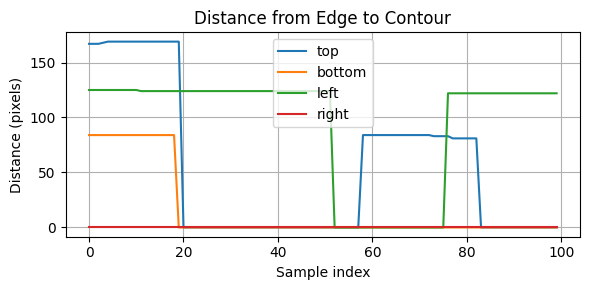

Piece #1
{'top': [((np.int32(10), 0), (np.int32(10), 165)), ((np.int32(15), 0), (np.int32(15), 165)), ((np.int32(21), 0), (np.int32(21), 165)), ((np.int32(27), 0), (np.int32(27), 165)), ((np.int32(33), 0), (np.int32(33), 165)), ((np.int32(39), 0), (np.int32(39), 165)), ((np.int32(45), 0), (np.int32(45), 165)), ((np.int32(51), 0), (np.int32(51), 166)), ((np.int32(57), 0), (np.int32(57), 166)), ((np.int32(63), 0), (np.int32(63), 166)), ((np.int32(69), 0), (np.int32(69), 166)), ((np.int32(75), 0), (np.int32(75), 166)), ((np.int32(81), 0), (np.int32(81), 166)), ((np.int32(87), 0), (np.int32(87), 166)), ((np.int32(93), 0), (np.int32(93), 166)), ((np.int32(99), 0), (np.int32(99), 166)), ((np.int32(105), 0), (np.int32(105), 166)), ((np.int32(111), 0), (np.int32(111), 166)), ((np.int32(117), 0), (np.int32(117), 166)), ((np.int32(123), 0), (np.int32(123), 164)), ((np.int32(128), 0), (np.int32(128), 0)), ((np.int32(134), 0), (np.int32(134), 0)), ((np.int32(140), 0), (np.int32(140), 0)), ((np.int

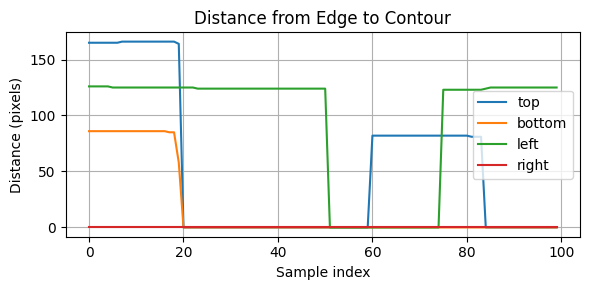

Piece #2
{'top': [((np.int32(10), 0), (np.int32(10), 80)), ((np.int32(14), 0), (np.int32(14), 80)), ((np.int32(19), 0), (np.int32(19), 80)), ((np.int32(24), 0), (np.int32(24), 80)), ((np.int32(28), 0), (np.int32(28), 80)), ((np.int32(33), 0), (np.int32(33), 79)), ((np.int32(38), 0), (np.int32(38), 79)), ((np.int32(42), 0), (np.int32(42), 79)), ((np.int32(47), 0), (np.int32(47), 79)), ((np.int32(52), 0), (np.int32(52), 79)), ((np.int32(56), 0), (np.int32(56), 79)), ((np.int32(61), 0), (np.int32(61), 79)), ((np.int32(66), 0), (np.int32(66), 79)), ((np.int32(71), 0), (np.int32(71), 79)), ((np.int32(75), 0), (np.int32(75), 79)), ((np.int32(80), 0), (np.int32(80), 81)), ((np.int32(85), 0), (np.int32(85), 81)), ((np.int32(89), 0), (np.int32(89), 81)), ((np.int32(94), 0), (np.int32(94), 81)), ((np.int32(99), 0), (np.int32(99), 81)), ((np.int32(103), 0), (np.int32(103), 81)), ((np.int32(108), 0), (np.int32(108), 81)), ((np.int32(113), 0), (np.int32(113), 81)), ((np.int32(118), 0), (np.int32(11

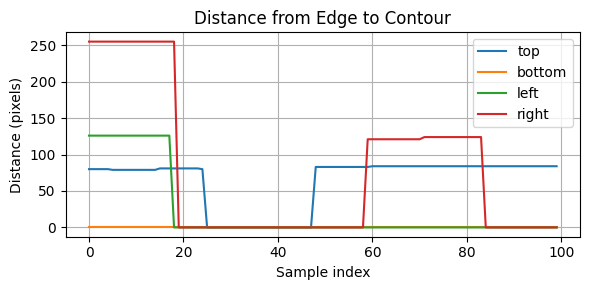

Piece #3
{'top': [((np.int32(10), 0), (np.int32(10), 0)), ((np.int32(14), 0), (np.int32(14), 0)), ((np.int32(19), 0), (np.int32(19), 0)), ((np.int32(24), 0), (np.int32(24), 0)), ((np.int32(28), 0), (np.int32(28), 0)), ((np.int32(33), 0), (np.int32(33), 0)), ((np.int32(38), 0), (np.int32(38), 0)), ((np.int32(42), 0), (np.int32(42), 0)), ((np.int32(47), 0), (np.int32(47), 0)), ((np.int32(52), 0), (np.int32(52), 0)), ((np.int32(56), 0), (np.int32(56), 0)), ((np.int32(61), 0), (np.int32(61), 0)), ((np.int32(66), 0), (np.int32(66), 0)), ((np.int32(70), 0), (np.int32(70), 0)), ((np.int32(75), 0), (np.int32(75), 0)), ((np.int32(80), 0), (np.int32(80), 0)), ((np.int32(84), 0), (np.int32(84), 0)), ((np.int32(89), 0), (np.int32(89), 0)), ((np.int32(94), 0), (np.int32(94), 0)), ((np.int32(98), 0), (np.int32(98), 0)), ((np.int32(103), 0), (np.int32(103), 0)), ((np.int32(108), 0), (np.int32(108), 0)), ((np.int32(112), 0), (np.int32(112), 0)), ((np.int32(117), 0), (np.int32(117), 0)), ((np.int32(122

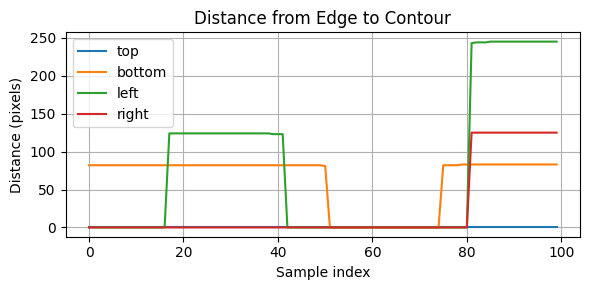

In [55]:
vectorized_edges = {}

for i, p in enumerate(smoothed_pieces):
    dist = measure_edge_distances(p, n_vectors=100, margin=10)
    vectorized_edges[f"piece_{i}"] = dist
    print(f"Piece #{i}")
    print(dist)
    plot_edge_distances(dist)

In [ ]:
def normalize_profile(profile):
    """Normalize distance profile to zero mean and unit variance."""
    p = np.array(profile, dtype=np.float32)
    p -= np.mean(p)
    p /= (np.std(p) + 1e-6)
    return p

def edge_similarity(edge1, edge2):
    """Compute similarity between two edges (higher = better match)."""
    e1 = normalize_profile(edge1)
    e2 = normalize_profile(edge2[::-1])  # reversed for complementary match
    # Use correlation as similarity metric
    return np.correlate(e1, e2, mode="valid")[0] / len(e1)

def match_pieces_by_edges(piece_distances):
    """
    piece_distances: dict of piece_id -> distance_dict (from measure_edge_distances)
    Returns list of (pieceA, edgeA, pieceB, edgeB, score)
    """
    matches = []
    pieces = list(piece_distances.keys())
    edges = ["top", "bottom", "left", "right"]

    for i, p1 in enumerate(pieces):
        for j, p2 in enumerate(pieces):
            if i >= j:
                continue  # avoid duplicate pairs

            for e1 in edges:
                for e2 in edges:
                    d1 = piece_distances[p1].get(e1, [])
                    d2 = piece_distances[p2].get(e2, [])
                    if not d1 or not d2:
                        continue

                    # Convert to distance magnitudes
                    prof1 = [np.hypot(e[1][0]-e[0][0], e[1][1]-e[0][1]) for e in d1]
                    prof2 = [np.hypot(e[1][0]-e[0][0], e[1][1]-e[0][1]) for e in d2]

                    # Match by correlation
                    score = edge_similarity(prof1, prof2)

                    matches.append((p1, e1, p2, e2, score))

    # Sort by best match (descending)
    matches.sort(key=lambda x: x[-1], reverse=True)
    return matches


matches = match_pieces_by_edges(vectorized_edges)

# Show top matches
for m in matches[:10]:
    print(f"{m[0]}:{m[1]} ↔ {m[2]}:{m[3]}   score={m[4]:.3f}")

piece_0:bottom ↔ piece_3:right   score=1.000
piece_1:bottom ↔ piece_3:right   score=0.985
piece_2:right ↔ piece_3:left   score=0.984
piece_0:left ↔ piece_2:top   score=0.974
piece_1:left ↔ piece_2:top   score=0.971
piece_2:top ↔ piece_3:bottom   score=0.971
piece_0:top ↔ piece_3:left   score=0.968
piece_2:left ↔ piece_3:right   score=0.967
piece_1:top ↔ piece_3:left   score=0.944
piece_2:right ↔ piece_3:right   score=0.858


## Assemble pieces

Following cell not working...

In [ ]:
EDGE_IDX = {"top": 0, "right": 1, "bottom": 2, "left": 3}
IDX_EDGE = {v: k for k, v in EDGE_IDX.items()}

def centroid_of_edge(dist_edge):
    """dist_edge: list of (start, end) pairs in local image coords.
       Return centroid of the end points (contour intersection points)."""
    ends = np.array([e[1] for e in dist_edge], dtype=np.float32)
    if len(ends) == 0:
        return np.array([0.0, 0.0], dtype=np.float32)
    return ends.mean(axis=0)

def rotate_image_and_points(img, points, angle_deg):
    """
    Rotate image around its center by angle_deg (positive = CCW).
    points: (N,2) coordinates relative to original image top-left.
    Returns: rotated_img, rotated_points (N,2), new_top_left_offset (x_shift, y_shift)
    new_top_left_offset is the translation from original image coordinate origin to new image origin.
    """
    h, w = img.shape[:2]
    cx, cy = w / 2.0, h / 2.0
    M = cv2.getRotationMatrix2D((cx, cy), angle_deg, 1.0)

    # compute new bounding dims
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # adjust translation in the transform
    M[0, 2] += (new_w / 2) - cx
    M[1, 2] += (new_h / 2) - cy

    # apply warp
    rotated = cv2.warpAffine(img, M, (new_w, new_h), flags=cv2.INTER_NEAREST, borderValue=(0,0,0))

    # transform points
    if len(points) > 0:
        ones = np.ones((points.shape[0], 1), dtype=np.float32)
        pts_h = np.hstack([points.astype(np.float32), ones])  # (N,3)
        rotated_pts = (M @ pts_h.T).T  # (N,2)
    else:
        rotated_pts = np.zeros((0,2), dtype=np.float32)

    # The offset from original top-left to new top-left is M applied to (0,0,1) minus (0,0)
    # But easier: if original origin maps to (tx, ty) in new image via M: tx = M[0,2], ty = M[1,2]
    offset = np.array([M[0,2], M[1,2]], dtype=np.float32)
    return rotated, rotated_pts, offset

def paste_with_mask(canvas, piece_img, piece_mask, top_left):
    """
    Paste piece_img onto canvas at top_left (x,y) using piece_mask (single channel, 255 inside).
    Returns canvas modified in place.
    """
    x, y = int(round(top_left[0])), int(round(top_left[1]))
    h, w = piece_img.shape[:2]
    H, W = canvas.shape[:2]

    x0 = max(0, x)
    y0 = max(0, y)
    x1 = min(W, x + w)
    y1 = min(H, y + h)

    if x1 <= x0 or y1 <= y0:
        return canvas  # completely outside

    # sub-regions
    px0 = x0 - x
    py0 = y0 - y
    px1 = px0 + (x1 - x0)
    py1 = py0 + (y1 - y0)

    roi_canvas = canvas[y0:y1, x0:x1]
    roi_piece = piece_img[py0:py1, px0:px1]
    roi_mask = piece_mask[py0:py1, px0:px1]

    # create 3-channel mask
    if len(roi_mask.shape) == 2:
        alpha = (roi_mask.astype(np.float32) / 255.0)[:,:,None]
    else:
        alpha = (cv2.cvtColor(roi_mask, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0)[:,:,None]

    # alpha blend (but because pieces are opaque, simple copy where mask==255)
    roi_canvas[:] = (roi_piece * alpha + roi_canvas * (1 - alpha)).astype(np.uint8)
    return canvas

def assemble_pieces_on_canvas(pieces_imgs, pieces_masks, piece_distances,
                              matches_sorted, canvas_size=(3000,3000), seed_piece_idx=0,
                              max_steps=100):
    """
    pieces_imgs: list of BGR images (masked pieces)
    pieces_masks: list of single-channel masks (255 inside piece)
    piece_distances: dict piece_id -> distances dict (as returned by measure_edge_distances)
    matches_sorted: list of tuples (pA_id, eA, pB_id, eB, score) sorted desc by score
    canvas_size: (W,H)
    seed_piece_idx: index of initial seed in pieces_imgs
    Returns: canvas image, placements dict (piece_id -> {top_left, rotation_deg, canvas_centroid})
    """

    # map piece_id strings to indices if needed
    # Accept both numeric indices or keys used in piece_distances (strings)
    # We'll use piece keys from piece_distances as canonical ids
    piece_ids = list(piece_distances.keys())
    id_to_idx = {pid: i for i, pid in enumerate(piece_ids)}

    # Prepare centroids for each piece and each edge (in local coords)
    edge_centroids = {}
    for pid in piece_ids:
        d = piece_distances[pid]
        edge_centroids[pid] = {}
        for edge in ["top","bottom","left","right"]:
            pts = d.get(edge, [])
            edge_centroids[pid][edge] = centroid_of_edge(pts)

    # Canvas and placement structures
    W, H = canvas_size
    canvas = np.zeros((H, W, 3), dtype=np.uint8)  # black background
    placements = {}  # pid -> dict(top_left, rotation_deg, centroid_abs)

    # helper to compute rotation needed for pB so that its edge eB faces opposite of pA:eA (considering pA rotation)
    def compute_rotation_for_alignment(pidA, eA, rotA_deg, pidB, eB):
        # global orientation indices
        eA_idx = EDGE_IDX[eA]
        eB_idx = EDGE_IDX[eB]
        eA_global = (eA_idx + int(round(rotA_deg / 90))) % 4
        # eB_global must be opposite
        desired_eB_global = (eA_global + 2) % 4
        # so rotB in 90-degree steps:
        rotB_steps = (desired_eB_global - eB_idx) % 4
        rotB_deg = int(rotB_steps * 90)
        return rotB_deg

    # Place seed in center
    seed_pid = piece_ids[seed_piece_idx]
    seed_img = pieces_imgs[id_to_idx[seed_pid]]
    seed_mask = pieces_masks[id_to_idx[seed_pid]]
    seed_h, seed_w = seed_img.shape[:2]
    seed_rotation = 0
    # compute centroid of whole piece mask (use moments)
    M = cv2.moments(seed_mask)
    if M["m00"] != 0:
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
    else:
        cx, cy = seed_w/2.0, seed_h/2.0
    # place so centroid at canvas center
    canvas_center = np.array([W/2.0, H/2.0], dtype=np.float32)
    top_left_seed = canvas_center - np.array([cx, cy], dtype=np.float32)

    paste_with_mask(canvas, seed_img, seed_mask, top_left_seed)
    placements[seed_pid] = {
        "top_left": top_left_seed,
        "rotation": seed_rotation,
        "centroid_abs": canvas_center
    }

    placed = set([seed_pid])
    unplaced = set(piece_ids) - placed

    steps = 0
    # We'll repeatedly try to find the best match where one piece is placed and the other not.
    while unplaced and steps < max_steps:
        steps += 1
        best_match = None
        best_score = -np.inf

        # find highest scoring match connecting placed <-> unplaced
        for (pA, eA, pB, eB, score) in matches_sorted:
            # ensure pA is placed and pB is unplaced OR vice versa
            if (pA in placed and pB in unplaced) or (pB in placed and pA in unplaced):
                if score > best_score:
                    best_score = score
                    best_match = (pA, eA, pB, eB, score)

        if best_match is None:
            break  # nothing left to attach

        pA, eA, pB, eB, score = best_match

        # which is placed?
        if pA in placed and pB in unplaced:
            placed_pid, placed_edge, unplaced_pid, unplaced_edge = pA, eA, pB, eB
        else:
            placed_pid, placed_edge, unplaced_pid, unplaced_edge = pB, eB, pA, eA

        # retrieve placement info
        placed_info = placements[placed_pid]
        placed_centroid_abs = np.array(placed_info["centroid_abs"], dtype=np.float32)
        rotA = placed_info["rotation"]

        # compute rotation for unplaced piece
        rotB = compute_rotation_for_alignment(placed_pid, placed_edge, rotA, unplaced_pid, unplaced_edge)

        # rotate unplaced image & mask and transform its edge centroid
        idxB = id_to_idx[unplaced_pid]
        imgB = pieces_imgs[idxB]
        maskB = pieces_masks[idxB]
        # original centroid for edge in local coords:
        edge_centroid_local = edge_centroids[unplaced_pid][unplaced_edge].reshape(1,2)

        rotated_imgB, rotated_edge_pts, offset = rotate_image_and_points(imgB, edge_centroid_local, rotB)
        rotated_maskB, _, _ = rotate_image_and_points(maskB, edge_centroid_local, rotB)[:3]  # rotates mask similarly

        rotated_edge_centroid = rotated_edge_pts[0]  # (x,y) relative to rotated image top-left

        # Now translate so rotated_edge_centroid lands on placed_centroid_abs
        top_left_B = placed_centroid_abs - rotated_edge_centroid

        # place the rotated piece
        paste_with_mask(canvas, rotated_imgB, rotated_maskB, top_left_B)

        # compute absolute centroid of piece (we can compute centroid of rotated mask)
        M2 = cv2.moments(rotated_maskB)
        if M2["m00"] != 0:
            cx2 = M2["m10"] / M2["m00"]
            cy2 = M2["m01"] / M2["m00"]
        else:
            cx2, cy2 = rotated_imgB.shape[1]/2.0, rotated_imgB.shape[0]/2.0
        centroid_abs_B = top_left_B + np.array([cx2, cy2], dtype=np.float32)

        placements[unplaced_pid] = {
            "top_left": top_left_B,
            "rotation": rotB,
            "centroid_abs": centroid_abs_B
        }

        placed.add(unplaced_pid)
        unplaced.remove(unplaced_pid)

    return canvas, placements

piece_masks = []
for img in masked_pieces:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > 0).astype(np.uint8) * 255
    piece_masks.append(mask)

canvas, placements = assemble_pieces_on_canvas(
    pieces_imgs=masked_pieces,
    pieces_masks=piece_masks,
    piece_distances=piece_distances,
    matches_sorted=matches,
    canvas_size=(3000, 3000),
    seed_piece_idx=0  # start with first piece
)

show_image(canvas)

for pid, info in placements.items():
    print(f"{pid} placed at {info['top_left']} with rotation {info['rotation']}°")

error: OpenCV(4.11.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::(anonymous namespace)::CvtHelper<cv::impl::(anonymous namespace)::Set<3, 4>, cv::impl::(anonymous namespace)::Set<1>, cv::impl::(anonymous namespace)::Set<0, 2, 5>>::CvtHelper(InputArray, OutputArray, int) [VScn = cv::impl::(anonymous namespace)::Set<3, 4>, VDcn = cv::impl::(anonymous namespace)::Set<1>, VDepth = cv::impl::(anonymous namespace)::Set<0, 2, 5>, sizePolicy = cv::impl::(anonymous namespace)::NONE]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


## UNUSED: Corner Detection

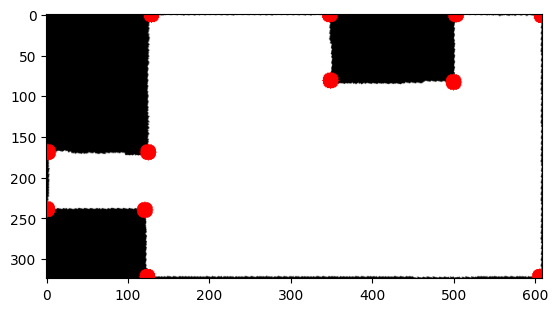

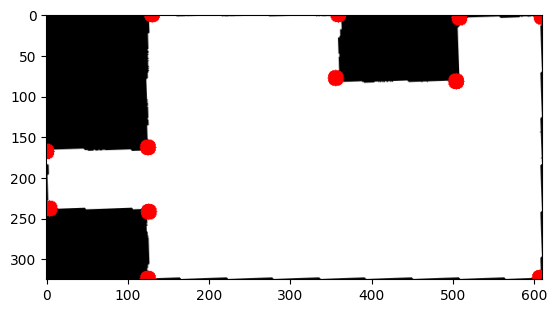

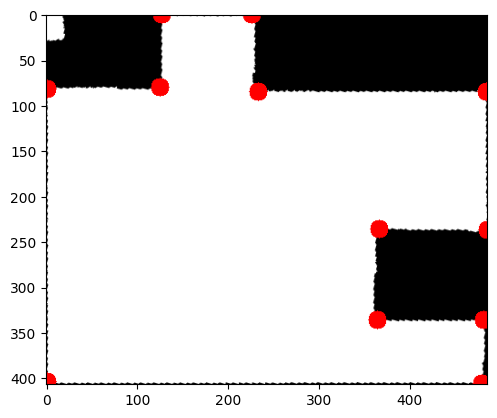

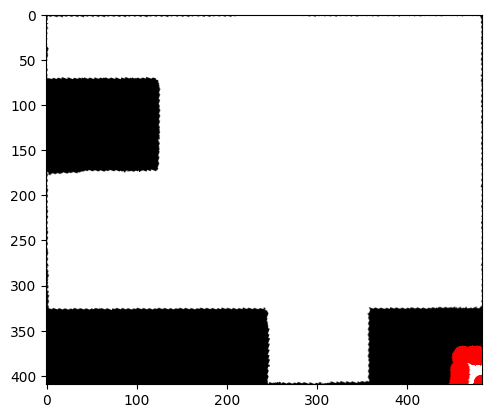

In [38]:
for p in pieces:
    piece_contour, _ = cv2.findContours(p, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    piece_contour = piece_contour[0]

    epsilon = 0.01 * cv2.arcLength(piece_contour, True)
    approx = cv2.approxPolyDP(piece_contour, epsilon, True)

    corners = []
    example_piece_image = cv2.cvtColor(p.copy(), cv2.COLOR_GRAY2RGB)
    for (x, y) in approx.reshape(-1, 2):
        corners.append((x, y))
        cv2.circle(example_piece_image, (x, y), 10, (0, 0, 255), -1)

    show_image(example_piece_image)

This is not _yet_ working reliably...

IDEA: Maybe select the edges which are closest to the image borders AND are the furthest apart.

In [39]:
# Corresponds to euclidian distance
def distance(p1, p2):
    return np.linalg.norm(np.array(p1)-np.array(p2))

distances = []
for p1, p2 in it.combinations(corners, 2):
    dist = distance(p1, p2)
    distances.append((p1, p2, dist))

distances.sort(key=lambda v: v[2], reverse=True)
distances

[((np.int32(456), np.int32(409)),
  (np.int32(483), np.int32(378)),
  np.float64(41.10960958218893)),
 ((np.int32(456), np.int32(409)),
  (np.int32(481), np.int32(379)),
  np.float64(39.05124837953327)),
 ((np.int32(461), np.int32(377)),
  (np.int32(483), np.int32(409)),
  np.float64(38.8329756778952)),
 ((np.int32(458), np.int32(407)),
  (np.int32(483), np.int32(378)),
  np.float64(38.28837943815329)),
 ((np.int32(456), np.int32(409)),
  (np.int32(477), np.int32(377)),
  np.float64(38.27531841800928)),
 ((np.int32(459), np.int32(380)),
  (np.int32(483), np.int32(409)),
  np.float64(37.64306044943742)),
 ((np.int32(458), np.int32(407)),
  (np.int32(481), np.int32(379)),
  np.float64(36.235341863986875)),
 ((np.int32(457), np.int32(403)),
  (np.int32(483), np.int32(378)),
  np.float64(36.069377593742864)),
 ((np.int32(456), np.int32(409)),
  (np.int32(472), np.int32(377)),
  np.float64(35.77708763999664)),
 ((np.int32(458), np.int32(407)),
  (np.int32(477), np.int32(377)),
  np.float64(

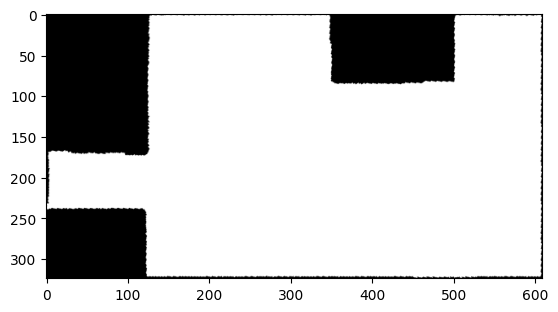

In [41]:
# Assumes all corners were detected (RISK)
# THIS IS WRONG
diag1 = distances[0]
diag2 = distances[1]

len1 = distances[2]
len2 = distances[3]
wid1 = distances[4]
wid2 = distances[5]

# Here we could test if the detected corners touch each other

example_piece_image = cv2.cvtColor(pieces[0].copy(), cv2.COLOR_GRAY2RGB)
cv2.circle(example_piece_image, wid2[0], 10, (0, 0, 255), -1)
show_image(example_piece_image)